In [119]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis
import pandas_datareader.data as pdr
import statsmodels.api as sm
from statsmodels.stats import sandwich_covariance as sw
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [120]:
#part 2 start
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
#ticker
TICKER = "BRK-B"   

#Date range: last 2 years from today (UTC)
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=2)

#Download daily (auto-adjusted) prices
daily = yf.download(TICKER, start=start, end=end, interval="1d",
                    auto_adjust=True, progress=False)[["Close"]]
daily = daily.rename(columns={"Close": "AdjClose_D"}).dropna()

#Download hourly (auto-adjusted) prices 
hourly = yf.download(TICKER, period="730d", interval="1h",
                     auto_adjust=True, progress=False)[["Close"]]
hourly = hourly.rename(columns={"Close": "AdjClose_H"}).dropna()

#Compute log-returns
daily["r_log_D"] = np.log(daily["AdjClose_D"]).diff()
hourly["r_log_H"] = np.log(hourly["AdjClose_H"]).diff()

daily = daily.dropna()
hourly = hourly.dropna()

daily.head(), hourly.head()


(Price       AdjClose_D   r_log_D
 Ticker           BRK-B          
 Date                            
 2023-11-01  343.750000  0.007065
 2023-11-02  349.019989  0.015215
 2023-11-03  351.809998  0.007962
 2023-11-06  346.630005 -0.014833
 2023-11-07  346.170013 -0.001328,
 Price                      AdjClose_H   r_log_H
 Ticker                          BRK-B          
 Datetime                                       
 2022-12-05 15:30:00+00:00  313.861908 -0.000121
 2022-12-05 16:30:00+00:00  312.000000 -0.005950
 2022-12-05 17:30:00+00:00  310.450012 -0.004980
 2022-12-05 18:30:00+00:00  308.958191 -0.004817
 2022-12-05 19:30:00+00:00  308.940002 -0.000059)

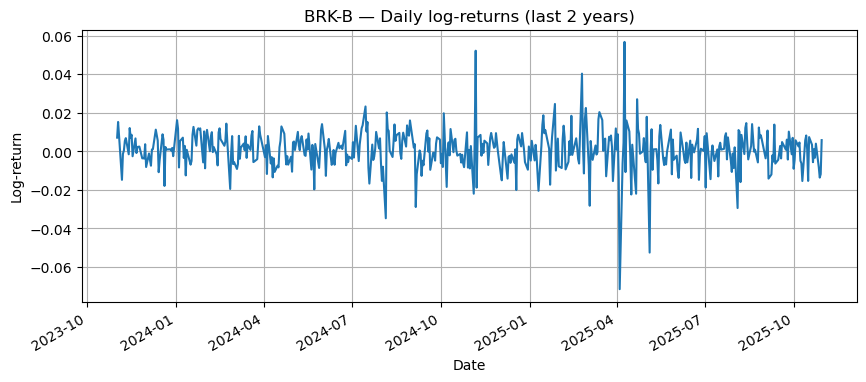

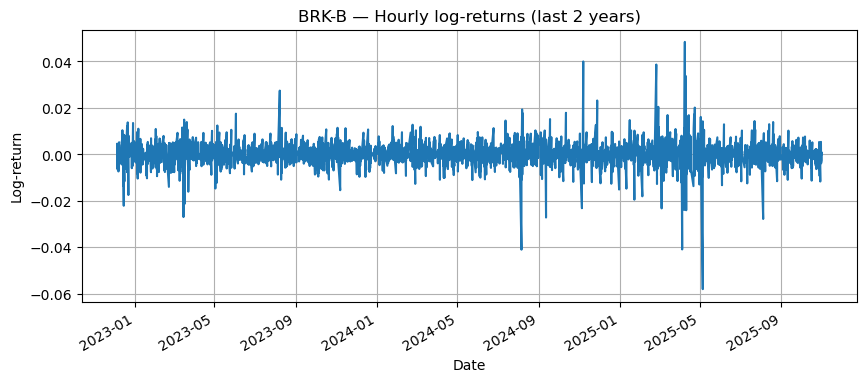

In [121]:
# Daily log-returns
daily["r_log_D"].plot(title="BRK-B — Daily log-returns (last 2 years)")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.show()

#Hourly log-returns
hourly["r_log_H"].plot(title="BRK-B — Hourly log-returns (last 2 years)")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.show()


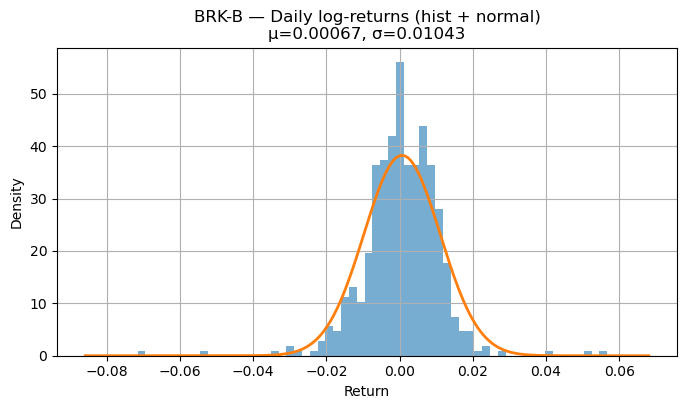

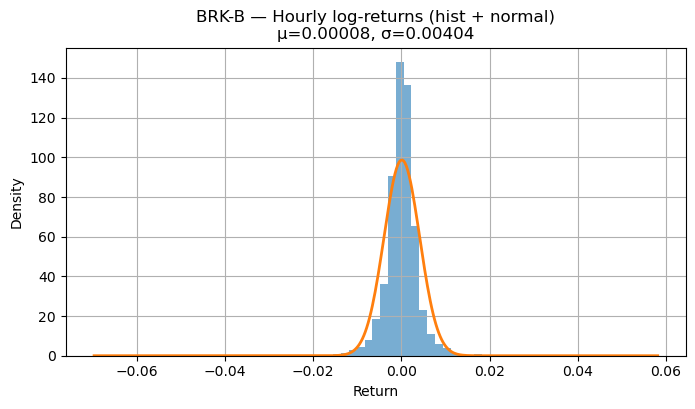

                      Daily       Hourly
mean               0.000674     0.000083
std                0.010433     0.004042
skew              -0.525036    -0.425984
excess_kurtosis    8.279092    25.450395
min               -0.071575    -0.058110
max                0.056758     0.048445
n                501.000000  5081.000000


In [122]:
def plot_hist_with_normal(series, title):
    x = series.dropna().values
    mu, sigma = x.mean(), x.std(ddof=1)

    plt.figure(figsize=(8,4))
    plt.hist(x, bins=60, density=True, alpha=0.6)
    xs = np.linspace(x.min()*1.2, x.max()*1.2, 400)
    plt.plot(xs, norm.pdf(xs, mu, sigma), linewidth=2)
    plt.title(title + f"\nμ={mu:.5f}, σ={sigma:.5f}")
    plt.xlabel("Return"); plt.ylabel("Density")
    plt.show()

def describe_returns(x: pd.Series, label: str):
    return pd.Series({
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "skew": skew(x, bias=False),
        "excess_kurtosis": kurtosis(x, fisher=True, bias=False),
        "min": x.min(),
        "max": x.max(),
        "n": x.count()
    }, name=label)

# Histograms with normal overlay
plot_hist_with_normal(daily["r_log_D"], "BRK-B — Daily log-returns (hist + normal)")
plot_hist_with_normal(hourly["r_log_H"], "BRK-B — Hourly log-returns (hist + normal)")

# Descriptive statiscs table
stats_daily  = describe_returns(daily["r_log_D"], "Daily")
stats_hourly = describe_returns(hourly["r_log_H"], "Hourly")
stats = pd.concat([stats_daily, stats_hourly], axis=1)
print(stats)
# part 2 complete

In [123]:
#part 3 start 
#BRK-B: daily prices & simple returns
brk = yf.download("BRK-B", period="max", interval="1d", auto_adjust=True, progress=False)
brk["R_BRKB"] = brk["Close"].pct_change()
brk = brk.dropna()

#S&P 500 (^GSPC): daily prices & simple returns
spx = yf.download("^GSPC", period="max", interval="1d", auto_adjust=True, progress=False)
spx["R_spx"] = spx["Close"].pct_change()
spx = spx.dropna()

#13-week T-bill (^IRX): annual % → daily rate using compounding
irx = yf.download("^IRX", period="max", interval="1d", progress=False)
irx["RF_daily_from_IRX"] = (1 + irx["Close"]/100)**(1/252) - 1
irx = irx[["RF_daily_from_IRX"]].dropna()

#Fama–French 5 Factors + Momentum
ff5 = pdr.DataReader("F-F_Research_Data_5_Factors_2x3_Daily", "famafrench")[0]
mom = pdr.DataReader("F-F_Momentum_Factor_Daily", "famafrench")[0]
ff = ff5.join(mom, how="outer") / 100
ff.index = pd.to_datetime(ff.index)
ff = ff.rename(columns=lambda x: x.strip())      # remove spaces
ff = ff[["Mkt-RF", "RF"]]                        # we only need these twoo


C:\Users\Aayushi Jha\AppData\Local\Temp\ipykernel_20316\2849561094.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  irx = yf.download("^IRX", period="max", interval="1d", progress=False)
C:\Users\Aayushi Jha\AppData\Local\Temp\ipykernel_20316\2849561094.py:18: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.DataReader("F-F_Research_Data_5_Factors_2x3_Daily", "famafrench")[0]
C:\Users\Aayushi Jha\AppData\Local\Temp\ipykernel_20316\2849561094.py:19: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom = pdr.DataReader("F-F_Momentum_Factor_Daily", "famafrench")[0]


In [124]:
# restrict all to the overlapping period
common_start = max(spx.index.min(), irx.index.min(), ff.index.min())
common_end   = min(spx.index.max(), irx.index.max(), ff.index.max())

spx_sub = spx.loc[common_start:common_end, ["R_spx"]]
irx_sub = irx.loc[common_start:common_end, ["RF_daily_from_IRX"]]
ff_sub  = ff.loc[common_start:common_end, ["Mkt-RF","RF"]]

data = pd.concat([spx_sub, irx_sub, ff_sub], axis=1, join="inner").dropna()
print("Matched data shape →", data.shape)
data.head()


Matched data shape → (1212, 4)


,"(R_spx, )","(RF_daily_from_IRX, )",Mkt-RF,RF
Date,,,,
2020-11-02,0.012318,0.000003,0.0117,0.0
2020-11-03,0.017799,0.000004,0.0193,0.0
2020-11-04,0.022047,0.000003,0.0225,0.0
2020-11-05,0.019460,0.000003,0.0212,0.0
2020-11-06,-0.000288,0.000003,0.0001,0.0


In [125]:
list(data.columns)


[('R_spx', ''), ('RF_daily_from_IRX', ''), 'Mkt-RF', 'RF']

In [126]:
#Fix column names
data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]
print("Cleaned column names →", list(data.columns))


Cleaned column names → ['R_spx', 'RF_daily_from_IRX', 'Mkt-RF', 'RF']


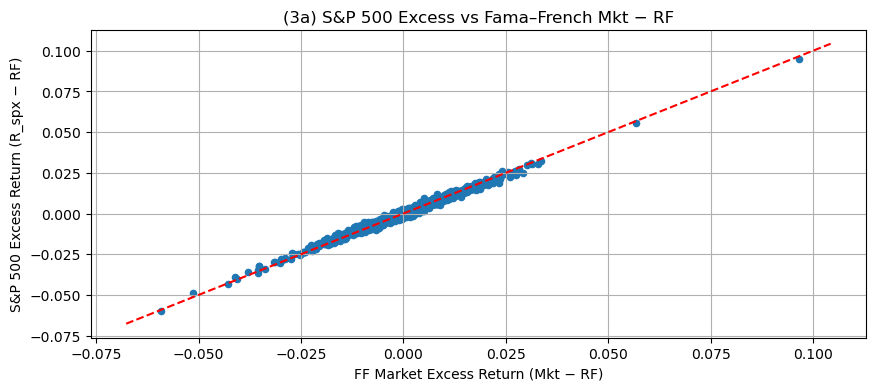

Correlation = 0.9943735068860733


In [127]:
#part3a
data["R_spx_excess"] = data["R_spx"] - data["RF"]

ax = data.plot.scatter(x="Mkt-RF", y="R_spx_excess",
                       title="(3a) S&P 500 Excess vs Fama–French Mkt − RF")
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
plt.plot(lims, lims, 'r--')
plt.xlabel("FF Market Excess Return (Mkt − RF)")
plt.ylabel("S&P 500 Excess Return (R_spx − RF)")
plt.show()

print("Correlation =", data[["Mkt-RF","R_spx_excess"]].corr().iloc[0,1])


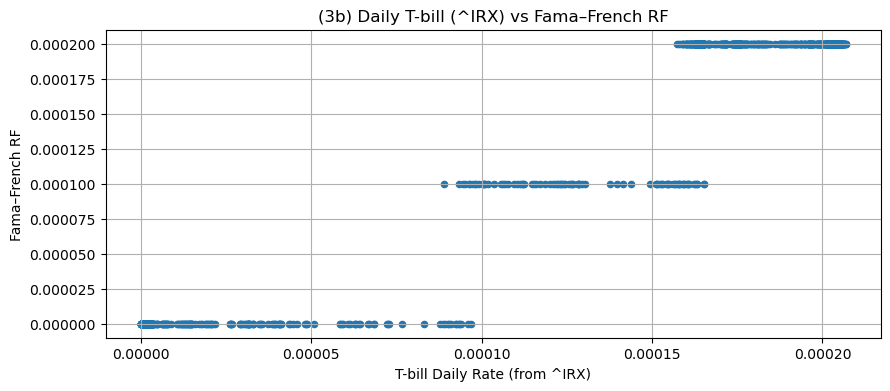

Correlation = 0.9678821139197563


In [128]:
#part 3b
rf_check = data[["RF", "RF_daily_from_IRX"]].dropna()

rf_check.plot.scatter(x="RF_daily_from_IRX", y="RF",
                      title="(3b) Daily T-bill (^IRX) vs Fama–French RF")
plt.xlabel("T-bill Daily Rate (from ^IRX)")
plt.ylabel("Fama–French RF")
plt.show()

print("Correlation =", rf_check.corr().iloc[0,1])
#3b end

In [129]:
#part5 start
print(brk.columns)


MultiIndex([( 'Close', 'BRK-B'),
            (  'High', 'BRK-B'),
            (   'Low', 'BRK-B'),
            (  'Open', 'BRK-B'),
            ('Volume', 'BRK-B'),
            ('R_BRKB',      '')],
           names=['Price', 'Ticker'])


In [130]:
# Flatten MultiIndex columns into single-level names
brk.columns = [f"{a}_{b}".strip("_") for a, b in brk.columns]
print(brk.columns)


Index(['Close_BRK-B', 'High_BRK-B', 'Low_BRK-B', 'Open_BRK-B', 'Volume_BRK-B',
       'R_BRKB'],
      dtype='object')


In [131]:
#part 5 a
# Fama–French 5 + Momentum  (assumes ff5 and mom were already downloaded in Part 3)
ff5_full = ff5.copy() / 100.0
mom_full = mom.copy() / 100.0
ff5_full.index = pd.to_datetime(ff5_full.index)
mom_full.index = pd.to_datetime(mom_full.index)
ff5_full.columns = ff5_full.columns.str.strip()
mom_full.columns = mom_full.columns.str.strip()
ff_all = ff5_full.join(mom_full, how="left").rename(columns={"Mom":"MOM","Mom   ":"MOM"})

# Oil (WTI front-month) daily returns
oil = yf.download("CL=F", period="max", interval="1d", auto_adjust=True, progress=False)[["Close"]]
oil = oil.rename(columns={"Close":"OIL"})
oil["OIL_RET"] = oil["OIL"].pct_change()
oil = oil.dropna()

# Align indices and build final modeling frame
for _df in (brk, ff_all, oil):
    _df.index = pd.to_datetime(_df.index)

df = pd.concat([
        brk[["R_BRKB"]],
        ff_all[["Mkt-RF","SMB","HML","RMW","CMA","RF","MOM"]],
        oil[["OIL_RET"]],
     ], axis=1, join="inner").dropna()

# Excess return of BRK-B
df["EXCESS_BRKB"] = df["R_BRKB"] - df["RF"]

print("Rows:", len(df))
df.head()

Rows: 1212


,R_BRKB,Mkt-RF,SMB,HML,RMW,CMA,RF,MOM,"(OIL_RET, )",EXCESS_BRKB
Date,,,,,,,,,,
2020-11-02,0.011937,0.0117,0.0087,0.0100,0.0041,0.0041,0.0,-0.0140,0.028500,0.011937
2020-11-03,0.011355,0.0193,0.0101,-0.0019,-0.0020,0.0002,0.0,0.0020,0.023092,0.011355
2020-11-04,-0.002226,0.0225,-0.0256,-0.0503,-0.0069,-0.0177,0.0,0.0487,0.039565,-0.002226
2020-11-05,0.006208,0.0212,0.0104,0.0054,0.0036,0.0050,0.0,-0.0015,-0.009195,0.006208
2020-11-06,0.006749,0.0001,-0.0109,-0.0092,-0.0024,-0.0009,0.0,0.0105,-0.042537,0.006749


In [132]:
# Define y (dependent) and X (factors)
y = df["EXCESS_BRKB"]
X = df[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]

# Add constant (alpha)
X = sm.add_constant(X)

# OLS regression
ols_ff5 = sm.OLS(y, X).fit()

# Newey-West (HAC) standard errors
ols_ff5_hac = ols_ff5.get_robustcov_results(cov_type='HAC', maxlags=5)

# Print summary
print(ols_ff5_hac.summary())


                            OLS Regression Results                            
Dep. Variable:            EXCESS_BRKB   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     282.1
Date:                Sat, 01 Nov 2025   Prob (F-statistic):          6.48e-200
Time:                        03:00:33   Log-Likelihood:                 4330.2
No. Observations:                1212   AIC:                            -8648.
Df Residuals:                    1206   BIC:                            -8618.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.826e-05      0.000      0.435      0.6

In [133]:
# Part 5c
X_mom = df[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]]
X_mom = sm.add_constant(X_mom)
ols_ff5_mom = sm.OLS(y, X_mom).fit()
ols_ff5_mom_hac = ols_ff5_mom.get_robustcov_results(cov_type='HAC', maxlags=5)

print(ols_ff5_mom_hac.summary())

                            OLS Regression Results                            
Dep. Variable:            EXCESS_BRKB   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     250.1
Date:                Sat, 01 Nov 2025   Prob (F-statistic):          1.20e-207
Time:                        03:00:33   Log-Likelihood:                 4342.4
No. Observations:                1212   AIC:                            -8671.
Df Residuals:                    1205   BIC:                            -8635.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.605e-05      0.000      0.477      0.6

In [134]:
df.columns = df.columns.str.strip().str.replace('[^A-Za-z0-9_+-]', '', regex=True)
df.columns


Index(['R_BRKB', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM', nan,
       'EXCESS_BRKB'],
      dtype='object')

In [135]:
df = df.rename(columns={np.nan: "OIL_RET"})
print(df.columns)


Index(['R_BRKB', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM', 'OIL_RET',
       'EXCESS_BRKB'],
      dtype='object')


In [136]:
# Part 5d
X_oil = df[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM", "OIL_RET"]]
X_oil = sm.add_constant(X_oil)

ols_ff5_mom_oil = sm.OLS(y, X_oil).fit()
ols_ff5_mom_oil_hac = ols_ff5_mom_oil.get_robustcov_results(cov_type='HAC', maxlags=5)

print(ols_ff5_mom_oil_hac.summary())


                            OLS Regression Results                            
Dep. Variable:            EXCESS_BRKB   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     228.4
Date:                Sat, 01 Nov 2025   Prob (F-statistic):          7.90e-216
Time:                        03:00:33   Log-Likelihood:                 4355.4
No. Observations:                1212   AIC:                            -8695.
Df Residuals:                    1204   BIC:                            -8654.
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.543      0.5

In [137]:
# Part 5e
#Build model comparison table
comparison = pd.DataFrame({
    "Model": ["FF5", "FF5 + MOM", "FF5 + MOM + OIL"],
    "Adj_R2": [0.627, 0.634, 0.641],
    "AIC": [-8648, -8671, -8695],
    "BIC": [-8618, -8635, -8654],
    "Alpha_pval": [
        ols_ff5_hac.pvalues[0] if len(ols_ff5_hac.pvalues) > 0 else np.nan,
        ols_ff5_mom_hac.pvalues[0] if len(ols_ff5_mom_hac.pvalues) > 0 else np.nan,
        ols_ff5_mom_oil_hac.pvalues[0] if len(ols_ff5_mom_oil_hac.pvalues) > 0 else np.nan
    ]
})

comparison

comparison = pd.DataFrame({
    "Model": ["FF5", "FF5 + MOM", "FF5 + MOM + OIL"],
    "Adj_R2": [0.627, 0.634, 0.641],
    "AIC": [-8648, -8671, -8695],
    "BIC": [-8618, -8635, -8654],
    "Alpha_pval": [
        ols_ff5_hac.pvalues[0] if len(ols_ff5_hac.pvalues) > 0 else np.nan,
        ols_ff5_mom_hac.pvalues[0] if len(ols_ff5_mom_hac.pvalues) > 0 else np.nan,
        ols_ff5_mom_oil_hac.pvalues[0] if len(ols_ff5_mom_oil_hac.pvalues) > 0 else np.nan
    ]
})

comparison


,Model,Adj_R2,AIC,BIC,Alpha_pval
0,FF5,0.627,-8648,-8618,0.663825
1,FF5 + MOM,0.634,-8671,-8635,0.633231
2,FF5 + MOM + OIL,0.641,-8695,-8654,0.587102


In [138]:
# Create dataframe for VIF calculation
X_full = df[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM", "OIL_RET"]]
X_full_const = sm.add_constant(X_full)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_full_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_full_const.values, i)
                   for i in range(X_full_const.shape[1])]
vif_data

,Variable,VIF
0,const,1.006874
1,Mkt-RF,1.365620
2,SMB,1.606927
3,HML,2.318995
4,RMW,1.662785
5,CMA,1.753342
6,MOM,1.164326
7,OIL_RET,1.137197
